# Lab Instructions

You are working as an analyst for a consulting agency that has been hired to study and improve productivity at a mid-sized company.  Morale is very low and, after speaking with employees, several common complaints kept coming up:

* New employees complained that more tenured employees were lazy and unproductive.
* More tenured employees complained that the newer employees didn't focus and were therefore unproductive.
* Managers were worried that remote workers might be less productive.
* In-person employees found it impossible to focus and be productive when their desk was in the open plan area.
* Many people said they had so much administrative work to do they could only be truly productive if they worked overtime.
* Everyone complained that there were too many meetings.

The consulting agency carefully collected data on a number of factors including number of years at the company, focus (higher is better), productivity (higher is better), department, meetings per week, and desk location can be found in Employee_productivity.csv.

1. Determine which feature - years at the company, hours worked, or focus - has the strongest linear relationship with productivity.  Show a visualization and calculate R-squared for all three relationships to justify your answer.

2. Build on that linear regression model to determine what other featuers also impact productivity. Using both visualzations and R-squared values, build a model that can predicts employee productivity at this company. Evaluate each feature in the dataset.

3. Write a short (a few sentences) summary of how the different factors in the data relate to employee productivity.  What recommendations would you make so that employees can be as productive as possible?



# Analysis

1. Focus had the biggest factor for productivity while years at the company and hours worked didn't really seem to matter very much.
   
2. Based on the other features, the next most impactful features on productivity were what depatment they worked (Marketing, Sales, and HR) and their desk location (Remote and Private Office). These negatively impact the productivity rating making them the next most important features to predict productivity.

3. The regression model showed that focus is the most important feature while things like the department, desk location, and working too many hours can hurt productivity. So to help employees be more productive, I would say the company should reduce distractions such as minimize open plan areas, give them more time to focus on their work by cutting back on team meetings, 

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

df = pd.read_csv('Employee_productivity.csv')

In [4]:
display(df.head())

,HoursWorked,FocusScore,ProductivityScore,Department,YearsAtCompany,TeamMeetingsPerWeek,DeskLocation
0,42.4,6.3,3127.96,Engineering,17,0,Open Plan
1,34.0,7.2,4742.60,HR,8,6,Private Office
2,47.2,5.6,2044.73,Sales,15,3,Remote
3,38.4,9.0,5818.92,HR,5,6,Private Office
4,36.4,2.5,1841.31,Sales,9,6,Remote


In [13]:
def apply_and_plot_polynomial_regression(degree, X_train, X_test, y_train, y_test):
    #Create poly features
    poly = PolynomialFeatures(degree)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    
    #Fit a linear regression model
    model = LinearRegression()
    model.fit(X_train_poly, y_train)
    
    #Predict and evaluate
    y_pred = model.predict(X_test_poly)
    r2 = r2_score(y_test, y_pred)
    
    #Plotting
    plt.figure(figsize = (10, 6))
    plt.scatter(X_train, y_train, alpha = 0.5, color = 'darkgreen', label = 'Train')
    plt.scatter(X_test, y_test, alpha = 0.5, color = 'darkgreen', label = 'Test')
    
    #Plot the curve/line
    X_fit = np.linspace(X_train.min(), X_train.max(), 200).reshape(-1, 1)
    y_fit = model.predict(poly.transform(X_fit))
    plt.plot(X_fit, y_fit, color = 'red', label = f'Polynomial Degree {degree} (R2: {r2: .2f})')

    plt.title(f'Polynomial Regression (Degree {degree})')
    plt.xlabel(feature_name)
    plt.ylabel(target_name)
    plt.legend()
    plt.grid(True)
    plt.show()

    return r2

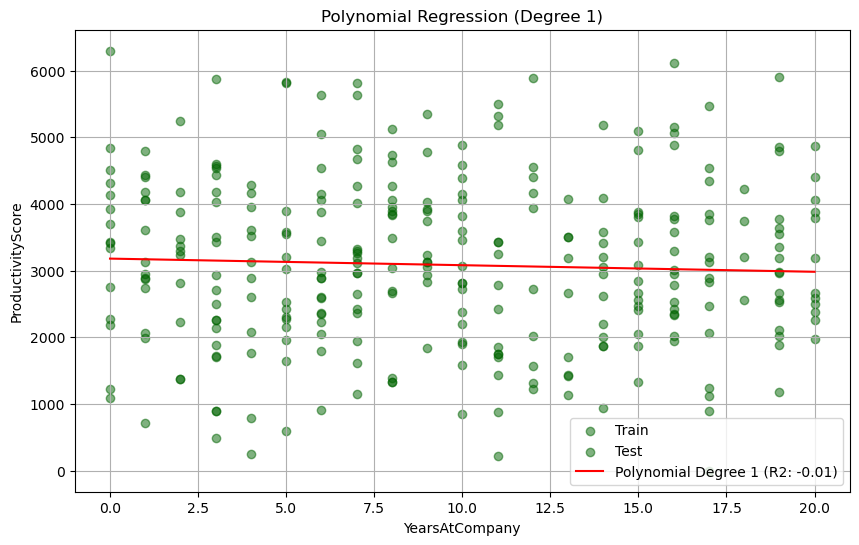

,feature,linear_R2
0,YearsAtCompany,-0.01292


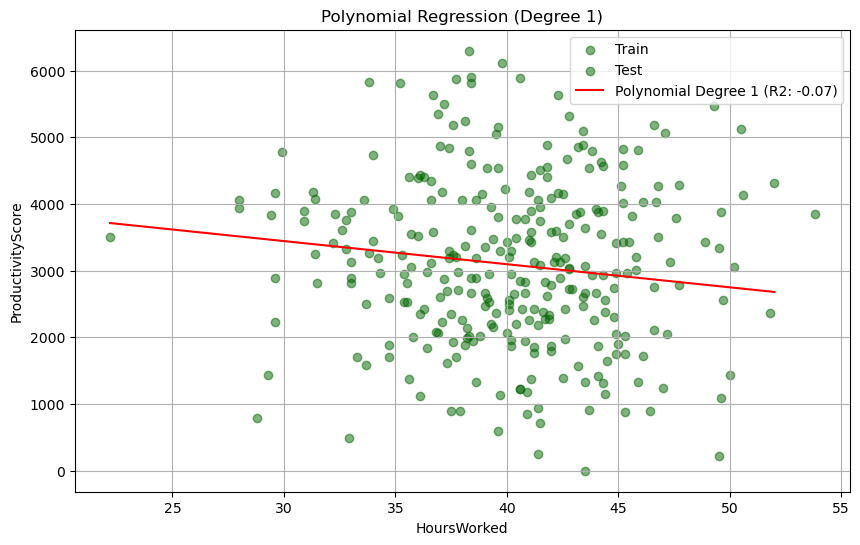

,feature,linear_R2
0,YearsAtCompany,-0.012920
1,HoursWorked,-0.065742


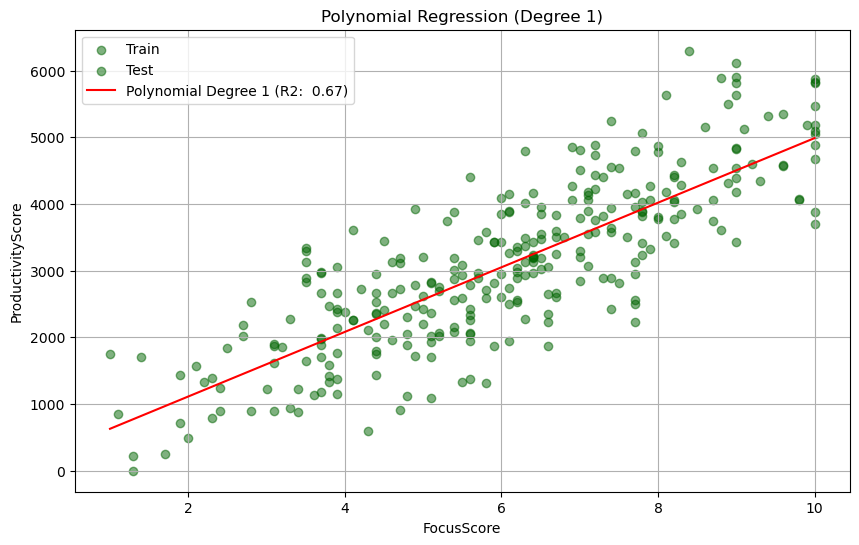

,feature,linear_R2
2,FocusScore,0.665098
0,YearsAtCompany,-0.012920
1,HoursWorked,-0.065742


In [16]:
df = pd.read_csv('Employee_productivity.csv')

target_name = 'ProductivityScore'
features = ['YearsAtCompany', 'HoursWorked', 'FocusScore']

results = []

for feature_name in features:
    X = df[[feature_name]].values
    y = df[target_name].values

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.30, random_state = 42)

    r2 = apply_and_plot_polynomial_regression(1, X_train, X_test, y_train, y_test)
    results.append({'feature': feature_name, 'linear_R2': r2})

    r2_table = pd.DataFrame(results).sort_values('linear_R2', ascending = False)
    display(r2_table)

,feature,coef
1,FocusScore,502.908955
5,Department_Marketing,-254.786164
8,DeskLocation_Remote,-227.651347
6,Department_Sales,-130.889068
7,DeskLocation_Private Office,-116.134768
4,Department_HR,-92.043816
3,TeamMeetingsPerWeek,35.477197
0,HoursWorked,-7.105687
2,YearsAtCompany,2.359167


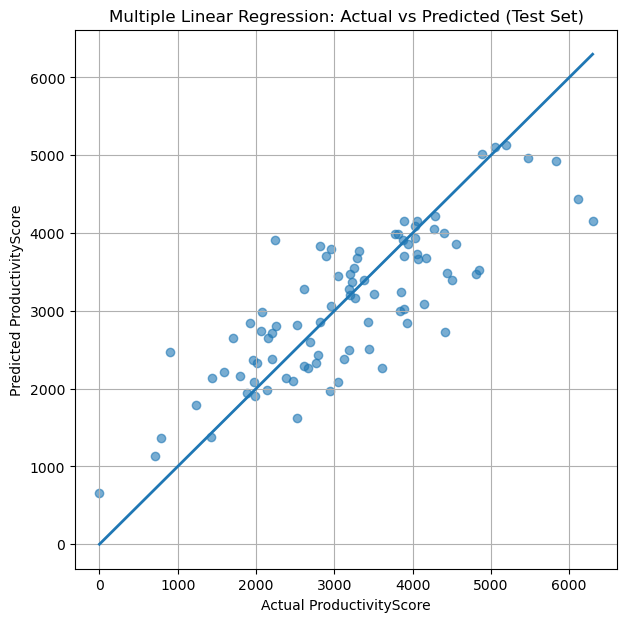

In [19]:
X = pd.concat([
    df[['HoursWorked', 'FocusScore', 'YearsAtCompany', 'TeamMeetingsPerWeek']],
    pd.get_dummies(df[['Department', 'DeskLocation']], drop_first=True)
], axis=1)
y = df[target_name].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

multi = LinearRegression()
multi.fit(X_train, y_train)

y_pred_train = multi.predict(X_train)
y_pred_test  = multi.predict(X_test)

coef_table = pd.DataFrame({'feature': X.columns, 'coef': multi.coef_})
coef_table = coef_table.sort_values('coef', key=lambda s: s.abs(), ascending=False)
display(coef_table)

plt.figure(figsize=(7,7))
plt.scatter(y_test, y_pred_test, alpha=0.6)
lim = [min(y_test.min(), y_pred_test.min()), max(y_test.max(), y_pred_test.max())]
plt.plot(lim, lim, linewidth=2)  # 45° reference line
plt.xlabel('Actual ProductivityScore')
plt.ylabel('Predicted ProductivityScore')
plt.title('Multiple Linear Regression: Actual vs Predicted (Test Set)')
plt.grid(True)
plt.show()